In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load dataset from file
# → Upload diabetes.csv from Kaggle to your Colab session first
#Dataset: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
df = pd.read_csv("diabetes.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print()
print(df.head())

Dataset loaded successfully!
Shape: (768, 9)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [4]:
import os

# Install Kaggle API client
!pip install -q kaggle

In [5]:
# Make a directory for Kaggle and move the kaggle.json file there
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

# Set permissions for the kaggle.json file
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset
# Dataset URL: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
!kaggle datasets download -d uciml/pima-indians-diabetes-database

# Unzip the downloaded file
!unzip -o pima-indians-diabetes-database.zip

print("Dataset downloaded and extracted successfully!")

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
License(s): CC0-1.0
100% 8.91k/8.91k [00:00<00:00, 16.0MB/s]

Archive:  pima-indians-diabetes-database.zip
  inflating: diabetes.csv            
Dataset downloaded and extracted successfully!


Now, you can run the original cell `6aa9f70b` to load the `diabetes.csv` file into a DataFrame, as it will now be present in your Colab environment.

### Figure 1: Extracting Top Highly Correlated Features

=== Correlation with Outcome ===
Glucose                     0.467
BMI                         0.293
Age                         0.238
Pregnancies                 0.222
DiabetesPedigreeFunction    0.174
Insulin                     0.131
SkinThickness               0.075
BloodPressure               0.065
Name: Outcome, dtype: float64



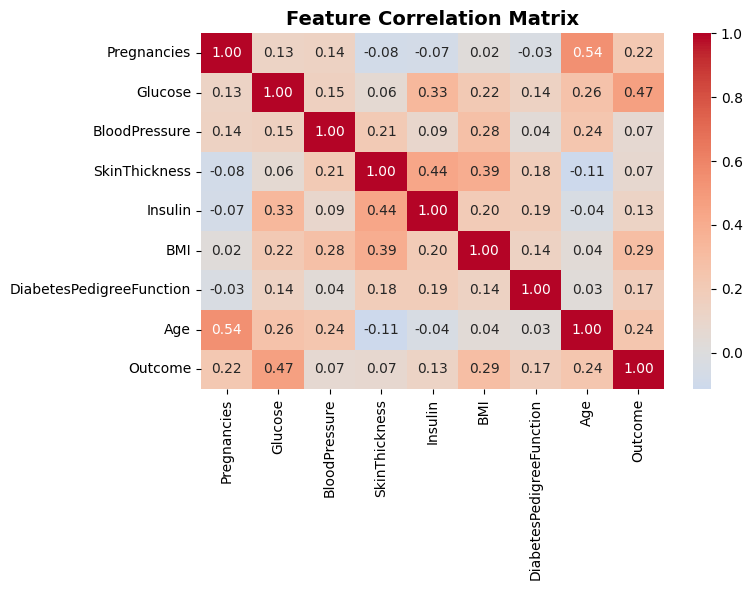

In [7]:
# Compute correlation of all features with the target (Outcome)
corr = df.corr()
target_corr = corr['Outcome'].drop('Outcome').sort_values(ascending=False)

print("=== Correlation with Outcome ===")
print(target_corr.round(3))
print()

# Visualise
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Figure 2: Isolating 3 Features and 1 Target Variable

In [8]:
# Pick the top 3 features most correlated with Outcome
feature_cols = ['Glucose', 'BMI', 'Age']
target_col   = 'Outcome'

# Remove rows where Glucose or BMI is 0 (missing values encoded as 0)
df_clean = df[(df['Glucose'] != 0) & (df['BMI'] != 0)].copy()

print("Cleaned dataset shape:", df_clean.shape)
print()
print(df_clean[feature_cols + [target_col]].head(10))
print()
print("Statistical Summary:")
print(df_clean[feature_cols + [target_col]].describe().round(2))

# Extract arrays and apply Min-Max Scaling
X_raw = df_clean[feature_cols].values.astype(float)   # (m, 3)
y_raw = df_clean[target_col].values.astype(float)      # (m,)

X_min = X_raw.min(axis=0)
X_max = X_raw.max(axis=0)
X_scaled = (X_raw - X_min) / (X_max - X_min)          # values in [0, 1]

m = X_scaled.shape[0]   # total number of samples

print()
print("X_scaled shape:", X_scaled.shape, "  <- (samples x 3 features)")
print("y shape       :", y_raw.shape)

Cleaned dataset shape: (752, 9)

    Glucose   BMI  Age  Outcome
0       148  33.6   50        1
1        85  26.6   31        0
2       183  23.3   32        1
3        89  28.1   21        0
4       137  43.1   33        1
5       116  25.6   30        0
6        78  31.0   26        1
7       115  35.3   29        0
8       197  30.5   53        1
10      110  37.6   30        0

Statistical Summary:
       Glucose     BMI     Age  Outcome
count   752.00  752.00  752.00   752.00
mean    121.94   32.45   33.31     0.35
std      30.60    6.93   11.71     0.48
min      44.00   18.20   21.00     0.00
25%      99.75   27.50   24.00     0.00
50%     117.00   32.30   29.00     0.00
75%     141.00   36.60   41.00     1.00
max     199.00   67.10   81.00     1.00

X_scaled shape: (752, 3)   <- (samples x 3 features)
y shape       : (752,)


### Figure 3: Applying Sigmoid Activation

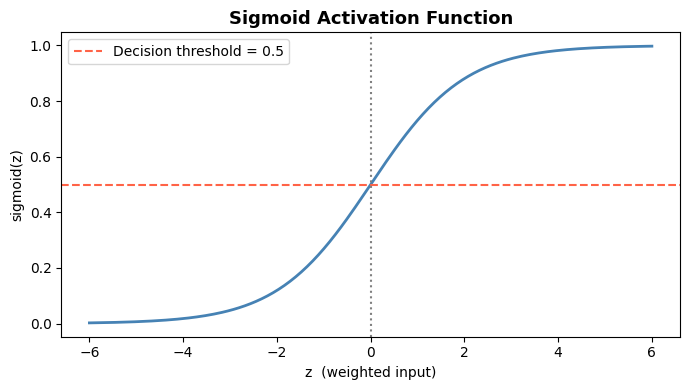

Sigmoid output on 5 sample rows:
[0.6287 0.5541 0.6263 0.5513 0.6208]


In [9]:
# Sigmoid activation function  (taken from Colab — Gradient Descent for Classification)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Visualise sigmoid curve
z_vals = np.linspace(-6, 6, 200)
plt.figure(figsize=(7, 4))
plt.plot(z_vals, sigmoid(z_vals), color='steelblue', linewidth=2)
plt.axhline(0.5, color='tomato', linestyle='--', label='Decision threshold = 0.5')
plt.axvline(0,   color='gray',   linestyle=':')
plt.title('Sigmoid Activation Function', fontsize=13, fontweight='bold')
plt.xlabel('z  (weighted input)')
plt.ylabel('sigmoid(z)')
plt.legend()
plt.tight_layout()
plt.show()

# Quick test on scaled dataset
sample_z = np.dot(X_scaled[:5], np.array([0.5, 0.3, 0.2]))
print("Sigmoid output on 5 sample rows:")
print(np.round(sigmoid(sample_z), 4))

### Figure 4: Defining the Layer and Initializing W1 (3x3) and W2 (3x1) with Random Seed

In [10]:
# Initialise weights with a random seed for reproducibility
np.random.seed(42)

# W1: (3x3) — connects 3 input features to 3 hidden nodes
W1 = np.random.randn(3, 3)

# W2: (3x1) — connects 3 hidden nodes to 1 output node
W2 = np.random.randn(3, 1)

learning_rate = 0.1

print("W1 (3x3):")
print(np.round(W1, 4))
print()
print("W2 (3x1):")
print(np.round(W2, 4))
print()
print("Learning Rate:", learning_rate)

# ReLU helper functions  (taken from Colab — Backpropagation in matrix form)
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

W1 (3x3):
[[ 0.4967 -0.1383  0.6477]
 [ 1.523  -0.2342 -0.2341]
 [ 1.5792  0.7674 -0.4695]]

W2 (3x1):
[[ 0.5426]
 [-0.4634]
 [-0.4657]]

Learning Rate: 0.1


### Figure 5: Training Loop (2 Iterations) — Forward Pass, Backpropagation, and Weight Update

Input X  (scaled): [[0.671  0.3149 0.4833]]
Target y         : 1  (Diabetic)

Starting Training...

--- ITERATION 1 ---
Prediction: 0.6981 | Loss: 0.0456
Updated 3x3 Weights (W1):
[[ 0.5077 -0.1477  0.6383]
 [ 1.5282 -0.2386 -0.2386]
 [ 1.5871  0.7607 -0.4763]] 

--- ITERATION 2 ---
Prediction: 0.7926 | Loss: 0.0215
Updated 3x3 Weights (W1):
[[ 0.5159 -0.154   0.6318]
 [ 1.532  -0.2415 -0.2416]
 [ 1.593   0.7561 -0.4809]] 



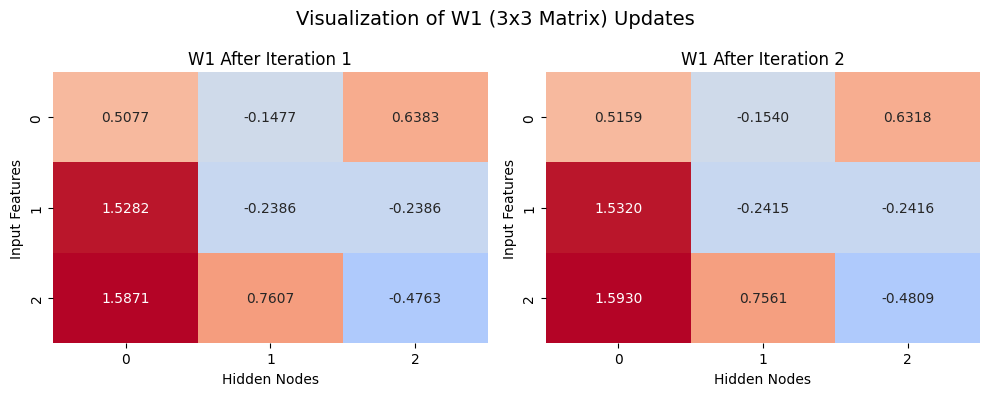

In [11]:
# Use one real row from the Pima dataset as input
X = X_scaled[0].reshape(1, -1)   # shape: (1, 3)
y = np.array([[y_raw[0]]])        # shape: (1, 1)

print(f"Input X  (scaled): {np.round(X, 4)}")
print(f"Target y         : {int(y[0][0])}  "
      f"({'Diabetic' if y[0][0]==1 else 'Not Diabetic'})")
print()

lr = learning_rate
w1_history = []

print("Starting Training...\n")

for i in range(2):
    print(f"--- ITERATION {i+1} ---")

    Z1 = np.dot(X, W1)
    H1 = relu(Z1)
    y_pred = np.dot(H1, W2)

    loss = 0.5 * np.sum((y_pred - y)**2)
    print(f"Prediction: {y_pred[0][0]:.4f} | Loss: {loss:.4f}")

    dy_pred = y_pred - y
    dW2 = np.dot(H1.T, dy_pred)

    dH1 = np.dot(dy_pred, W2.T)
    dZ1 = dH1 * relu_derivative(Z1)
    dW1 = np.dot(X.T, dZ1)

    W1 = W1 - (lr * dW1)
    W2 = W2 - (lr * dW2)

    print("Updated 3x3 Weights (W1):")
    print(np.round(W1, 4), "\n")

    w1_history.append(W1.copy())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Visualization of W1 (3x3 Matrix) Updates", fontsize=14)

sns.heatmap(w1_history[0], annot=True, cmap="coolwarm", center=0, fmt=".4f",
            ax=axes[0], cbar=False)
axes[0].set_title("W1 After Iteration 1")
axes[0].set_xlabel("Hidden Nodes")
axes[0].set_ylabel("Input Features")

sns.heatmap(w1_history[1], annot=True, cmap="coolwarm", center=0, fmt=".4f",
            ax=axes[1], cbar=False)
axes[1].set_title("W1 After Iteration 2")
axes[1].set_xlabel("Hidden Nodes")
axes[1].set_ylabel("Input Features")

plt.tight_layout()
plt.show()